In [87]:
from simfile import SimFile
from simulation import Simulation
from validation import switchAllEffectsOff
import os
import math
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as constants

In [88]:
sim = Simulation("mechanicalVignetting")
switchAllEffectsOff(sim)
sim.outputDir = os.environ["PLATO_WORKDIR"]

# One full-frame exposure

sim["ObservingParameters/NumExposures"] = 1
sim["SubField/NumRows"] = 4510
sim["SubField/NumColumns"] = 4510

# Make sure no sources are located in the sub-field

sim["ObservingParameters/DecPointing"] = -sim["ObservingParameters/DecPointing"]

# Enable mechanical vignetting

sim["CCD/IncludeMechanicalVignetting"] = "yes"

In [89]:
pixelSize = sim["CCD/PixelSize"] / 1000.0

# Without open-shutter smearing

In [90]:
outputWithoutOSS = sim.run(removeOutputFile = True)


2019-04-04 12:02:53 WARNING Simulation: no information about detected stars to write to HDF5
2019-04-04 12:02:53 WARNING Camera: No star positions to write to HDF5 file.



In [91]:
normalizationFactorWithoutOSS = outputWithoutOSS.getImage(0)[0][0]
imageNoOffsetWithoutOSS = outputWithoutOSS.getImage(0)

In [92]:
xFP, yFP = rf.focalPlaneCoordinatesFromGnomonicRadialDistance(np.deg2rad(18.8876), sim["Camera/FocalLength/ConstantValue"] * 1000, 0)
x, y = rf.focalPlaneToPixelCoordinates(xFP, yFP, 18, 0, 0, 0)
intersection = math.sqrt(x**2 - sim["CCD/NumColumns"]**2)

[Text(0, 0, ''),
 Text(0, 0, ''),
 Text(0, 0, '1000'),
 Text(0, 0, '2000'),
 Text(0, 0, '3000'),
 Text(0, 0, '4000'),
 Text(0, 0, ''),
 Text(0, 0, 'y$_{FOV}^*$'),
 Text(0, 0, 'R$_{FOV}$')]

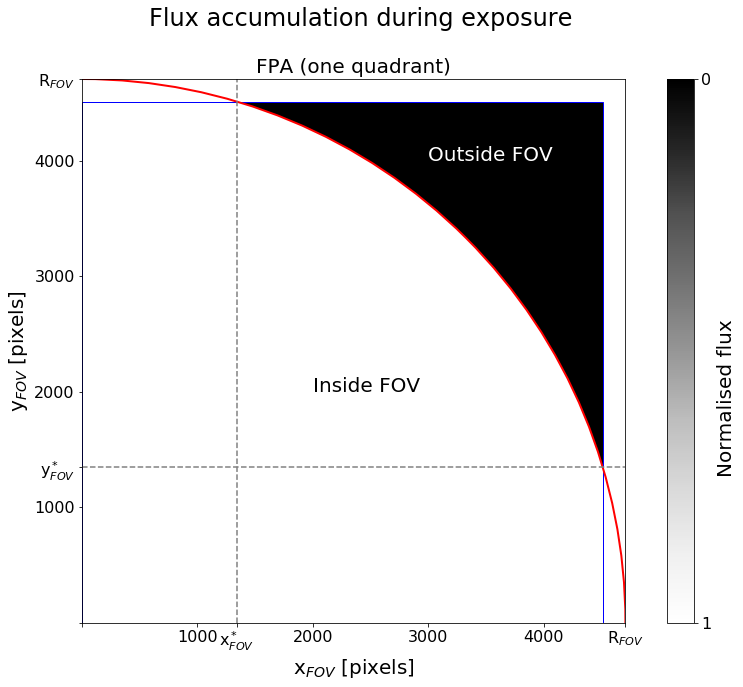

In [99]:
intersection = np.where(imageNoOffsetWithoutOSS == 0)[0][0]
#intersection = 1339.5569086073087
radiusPixels = math.sqrt(sim["CCD/NumRows"]**2 + intersection**2)

fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)

rect = plt.Rectangle((0,0), sim["CCD/NumColumns"], sim["CCD/NumRows"])
ax.add_patch(rect)
rect.set_edgecolor("b")
rect.set_facecolor("none")

circ = plt.Circle((0,0), radius = radiusPixels, color = "white", linewidth = 2)
ax.add_patch(circ)
circ.set_edgecolor("r")
circ.set_facecolor("none")

im = plt.imshow((-imageNoOffsetWithoutOSS) / (imageNoOffsetWithoutOSS[0][0]), origin='lower', cmap='Greys')

plt.text(2000, 2000, "Inside FOV", fontsize = 20)
plt.text(3000, 4000, "Outside FOV", fontsize = 20, color = "w")
#plt.text(600, 4000, "Edge of FOV ($R_{FOV}$)" + r'$\rightarrow$', fontsize = 20, color = "r")

plt.suptitle("Flux accumulation during exposure", fontsize = 24)
plt.title("FPA (one quadrant)", fontsize = 20)
plt.xlabel("x$_{FOV}$ [pixels]", fontsize = 20)
plt.ylabel("y$_{FOV}$ [pixels]", fontsize = 20)


cbar = fig.colorbar(im, ticks=[-1, 0])
cbar.ax.set_yticklabels(['1', '0'], fontsize = 16)  # vertically oriented colorbar

plt.text(5500, 2500, "Normalised flux", fontsize = 20, rotation = 90)

plt.axvline(x = intersection, linestyle = "--", color =  "gray")
plt.axhline(y = intersection, linestyle = "--", color =  "gray")

plt.xticks(list(plt.xticks()[0]) + [intersection, radiusPixels])
plt.yticks(list(plt.yticks()[0]) + [intersection, radiusPixels])
plt.xlim([0, radiusPixels])
plt.ylim([0, radiusPixels])

labels = [item.get_text() for item in ax.get_xticklabels()]
labels[2] = '1000'
labels[3] = '2000'
labels[4] = '3000'
labels[5] = '4000'
labels[7] = 'x$_{FOV}^*$'
labels[8] = 'R$_{FOV}$'
ax.set_xticklabels(labels, fontsize = 16)

labels[7] = 'y$_{FOV}^*$'
ax.set_yticklabels(labels, fontsize = 16)

# With open-shutter smearing

In [94]:
sim["CCD/IncludeOpenShutterSmearing"] = "yes"
outputWithOSS = sim.run(removeOutputFile = True)


2019-04-04 12:03:02 WARNING Simulation: no information about detected stars to write to HDF5
2019-04-04 12:03:02 WARNING Camera: No star positions to write to HDF5 file.



In [95]:
diffImage = outputWithOSS.getImage(0) - outputWithoutOSS.getImage(0)  # Contribution from open-shutter smearing
normalizationFactor = diffImage[0][0]

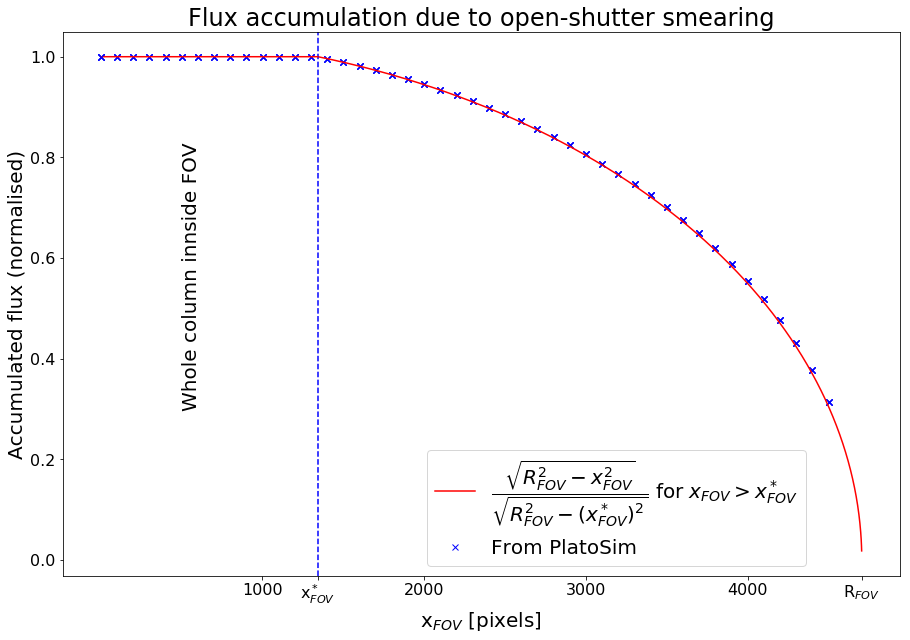

In [96]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)

for row in range(0, sim["SubField/NumRows"], 1000):
    for column in range(0, sim["SubField/NumColumns"], 100):
        try:
            plt.plot([column + 0.5], diffImage[row][column] / normalizationFactor, "bx")
        except:
            pass

label = "$\dfrac{\sqrt{R_{FOV}^2 - x_{FOV}^2}}{\sqrt{R_{FOV}^2 - (x_{FOV}^*)^2}}$ for $x_{FOV} > x_{FOV}^*$"
r = np.arange(intersection, radiusPixels)
#r = np.arange(intersection, sim["CCD/NumColumns"])
#r = np.append(r, radiusPixels)
y = np.sqrt(radiusPixels**2 - r**2) / np.sqrt(radiusPixels**2 - intersection**2)
plt.plot(r, y, "r", label = label)

ax.axvline(x = intersection, color = "b", linestyle = "--")

plt.plot(np.arange(math.floor(intersection)), np.ones(math.floor(intersection)), "r")

plt.text(500, 0.8, "Whole column innside FOV", fontsize = 20, rotation = 90)
#plt.text(3000, 0.9, "$\dfrac{\sqrt{R_{FOV}^2 - x_{FOV}^2}}{\sqrt{R_{FOV}^2 - (x_{FOV}^*)^2}}$", fontsize = 20)

plt.title("Flux accumulation due to open-shutter smearing", fontsize = 24)
plt.xlabel("x$_{FOV}$ [pixels]", fontsize = 20)
plt.ylabel("Accumulated flux (normalised)", fontsize = 20)

x = [intersection, radiusPixels, 1000, 2000, 3000, 4000]
labels = ["x$_{FOV}^*$", "R$_{FOV}$", "1000", "2000", "3000", "4000"]

plt.plot([0], [1], "bx", label = "From PlatoSim")

#labels = [item.get_text() for item in ax.get_xticklabels()]
#labels[1] = 'Testing'

#ax.set_xticklabels(labels)
plt.xticks(x, labels, fontsize = 16)

for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

plt.legend(loc='lower right',  bbox_to_anchor=(0.9, 0.0), fontsize = 20)

plt.show()